# **Não supervisionado: Kmeans**
- agrupar propriedades a partir das features

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("dataset_tratado.csv")

features = ['price', 'area', 'bedrooms', 'baths', 'price_per_sqm']

X = df[features]
X = X.replace([np.inf, -np.inf], np.nan).dropna()

### Adicionando scaler e definindo quantidade de clusters

In [80]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

### Silhouette Score
- Mede quão bem separados e coerentes internamente estão os clusters. -1 a 1

In [81]:
sil_score = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette Score: {sil_score:.3f}\n")

Silhouette Score: 0.320



### Comparação de resultados

In [82]:
tab = pd.crosstab(df['cluster'], df['property_type'])
print("Comparação entre clusters e tipos reais:\n")
print(tab)

Comparação entre clusters e tipos reais:

property_type  Farm House   Flat  House  Lower Portion  Penthouse  Room  \
cluster                                                                   
0                       5    254  16346             84         38     0   
1                       0   5289  17371            225         47     0   
2                       0  12495   4895           1451         65   137   
3                      13   2033   5738           1781         46     2   
4                      51      0      0              0          0     0   

property_type  Upper Portion  
cluster                       
0                        146  
1                        598  
2                       1547  
3                       2479  
4                          0  


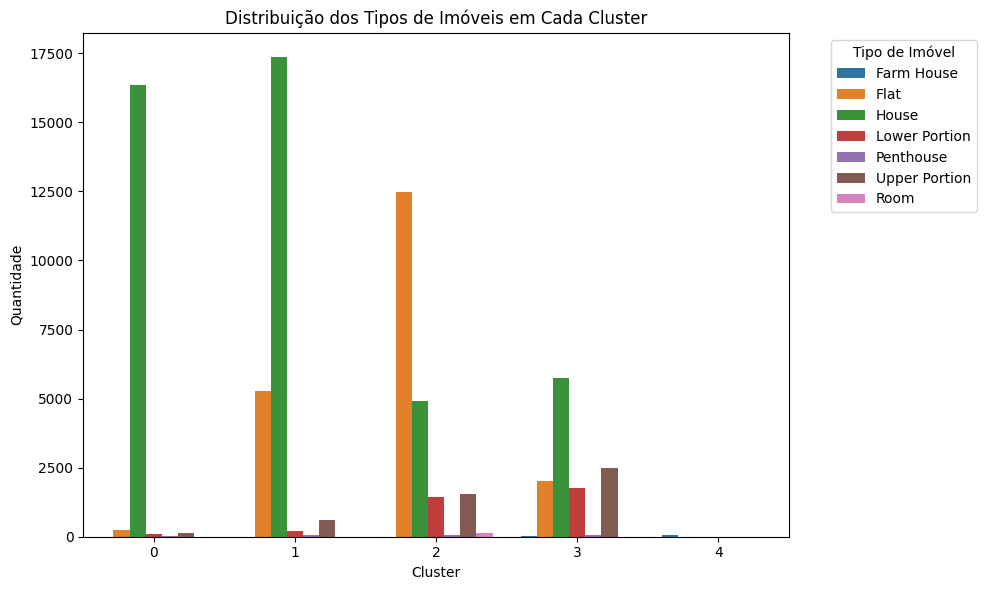

In [83]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='cluster', hue='property_type', palette='tab10')
plt.title('Distribuição dos Tipos de Imóveis em Cada Cluster')
plt.xlabel('Cluster')
plt.ylabel('Quantidade')
plt.legend(title='Tipo de Imóvel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Clusters de Imóveis (Área x Preço por m²)

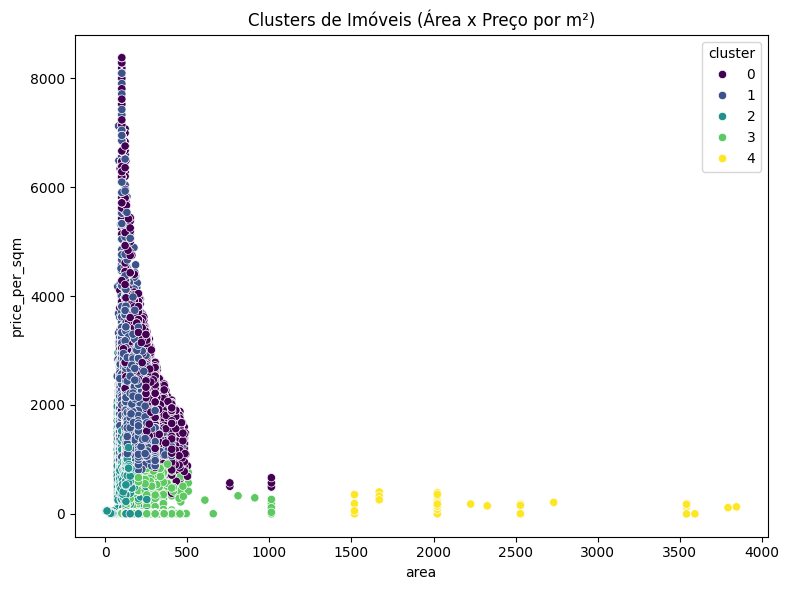

In [84]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, x='area', y='price_per_sqm', hue='cluster', palette='viridis'
)
plt.title('Clusters de Imóveis (Área x Preço por m²)')
plt.tight_layout()
plt.show()

### ARI:
- Mede quanto os clusters obtidos batem com os rótulos reais. 0 a 1

In [85]:
ari = adjusted_rand_score(df['property_type'], df['cluster'])
print(f"Adjusted Rand Index (comparação com tipos reais): {ari:.3f}")

Adjusted Rand Index (comparação com tipos reais): 0.153
